# Toroidal VAE
### Template Space S¹x...xS¹

In [81]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [82]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [83]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.vm_toroidal_vae as model
import lib.trainer as trainer
import lib.utils as utils

from types import SimpleNamespace



### General set up

In [84]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Experiment Configurations

In [85]:
loader_config = {
    "dataset_name": "s1_synthetic",
    "batch_size": 128,
    "synthetic_rotation": "random",
    "n_times": 10000,
    "radius": 1.0,
    "n_wiggles": 0,
    "geodesic_distortion_amp": 0.1,
    "embedding_dim": 3,
    "noise_var": 0.0001,
    "geodesic_distortion_func": "wiggles",
    "plot_dataset": True
}

model_config = {
    'data_dim': loader_config["embedding_dim"],
    'latent_dim': 1,
    'sftbeta': 1,
    'device': "cpu",
    'encoder_width': 5,
    'encoder_depth': 2,
    'decoder_width': 5,
    'decoder_depth': 3
}

trainer_config = {
    'num_epochs': 15,
    'log_interval': 100,
    'device': "cpu",
    'recon_loss': "MSE"
}

misc_config = {
    "n_grid_points": 2000,  # to compute curvature
    "manifold_dim": 1,
}

config_dict = {}
config_dict.update(loader_config)
config_dict.update(model_config)
config_dict.update(trainer_config)
config_dict.update(misc_config)

config = SimpleNamespace(**config_dict)

 ### Dataloader

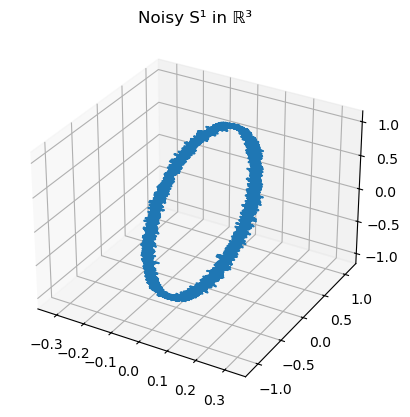

In [86]:
dataloader = dataloader.load_synthetic_ds(loader_config)
train_loader, test_loader = dataloader

### Model

In [87]:
toroidal_model = model.VMToroidalVAE(model_config)

### Optimizer

In [88]:
learning_rate = 0.001

toroidal_optimizer = optim.Adam(toroidal_model.parameters(), lr=learning_rate)

### Train and evaluate model

In [89]:
toroidal_history = trainer.MVAETrainer(toroidal_model, dataloader, toroidal_optimizer, trainer_config).train()

Trainer successfully initialized.
Training the vm_toroidalVAE model.
Starting epoch 1/15
Epoch 1/15, Train Loss: 1.9449, Test Loss: 1.8565
--------------------------------------------------
Starting epoch 2/15
Epoch 2/15, Train Loss: 1.7367, Test Loss: 1.6433
--------------------------------------------------
Starting epoch 3/15
Epoch 3/15, Train Loss: 1.5028, Test Loss: 1.3740
--------------------------------------------------
Starting epoch 4/15
Epoch 4/15, Train Loss: 1.2869, Test Loss: 1.2500
--------------------------------------------------
Starting epoch 5/15
Epoch 5/15, Train Loss: 1.2410, Test Loss: 1.2362
--------------------------------------------------
Starting epoch 6/15
Epoch 6/15, Train Loss: 1.2350, Test Loss: 1.2345
--------------------------------------------------
Starting epoch 7/15
Epoch 7/15, Train Loss: 1.2336, Test Loss: 1.2324
--------------------------------------------------
Starting epoch 8/15
Epoch 8/15, Train Loss: 1.2314, Test Loss: 1.2297
--------------

### Visualization 

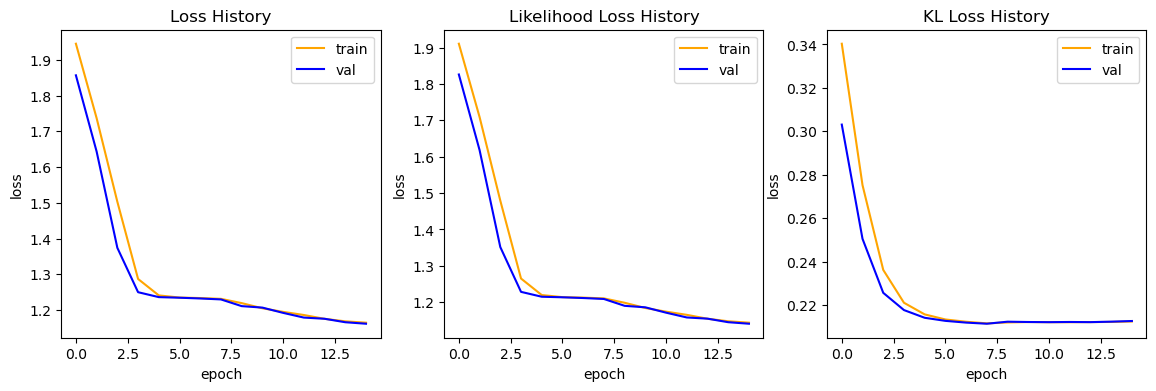

In [90]:
utils.show_training_history(toroidal_history)

#### Plot latent space

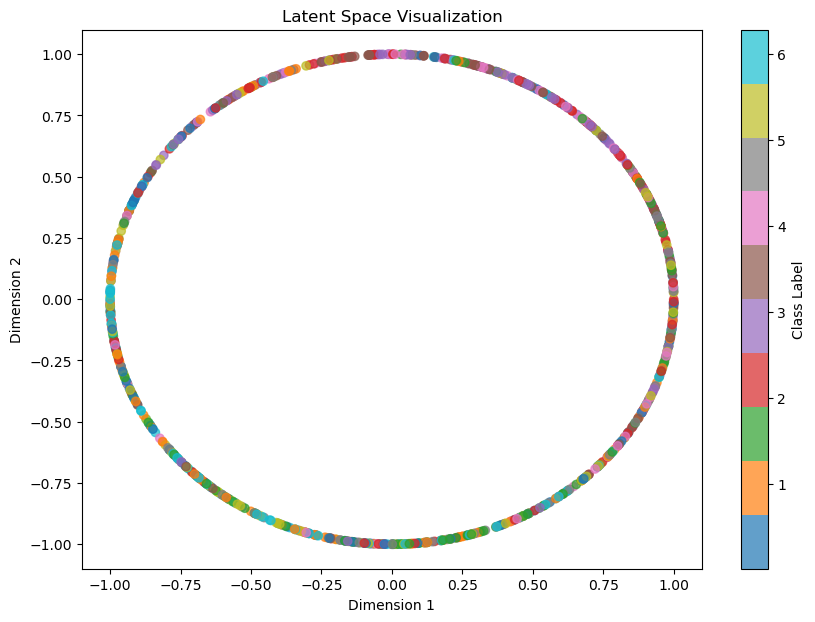

In [91]:
utils.plot_euclidean_latent_space(toroidal_model, test_loader, n_samples=10000)

#### Compute curvature error

Computing learned curvature...
Computation time: 19.936 s
Computing true curvature for synthetic data...
Computation time: 14.989 s
Computing curvature error for synthetic data...


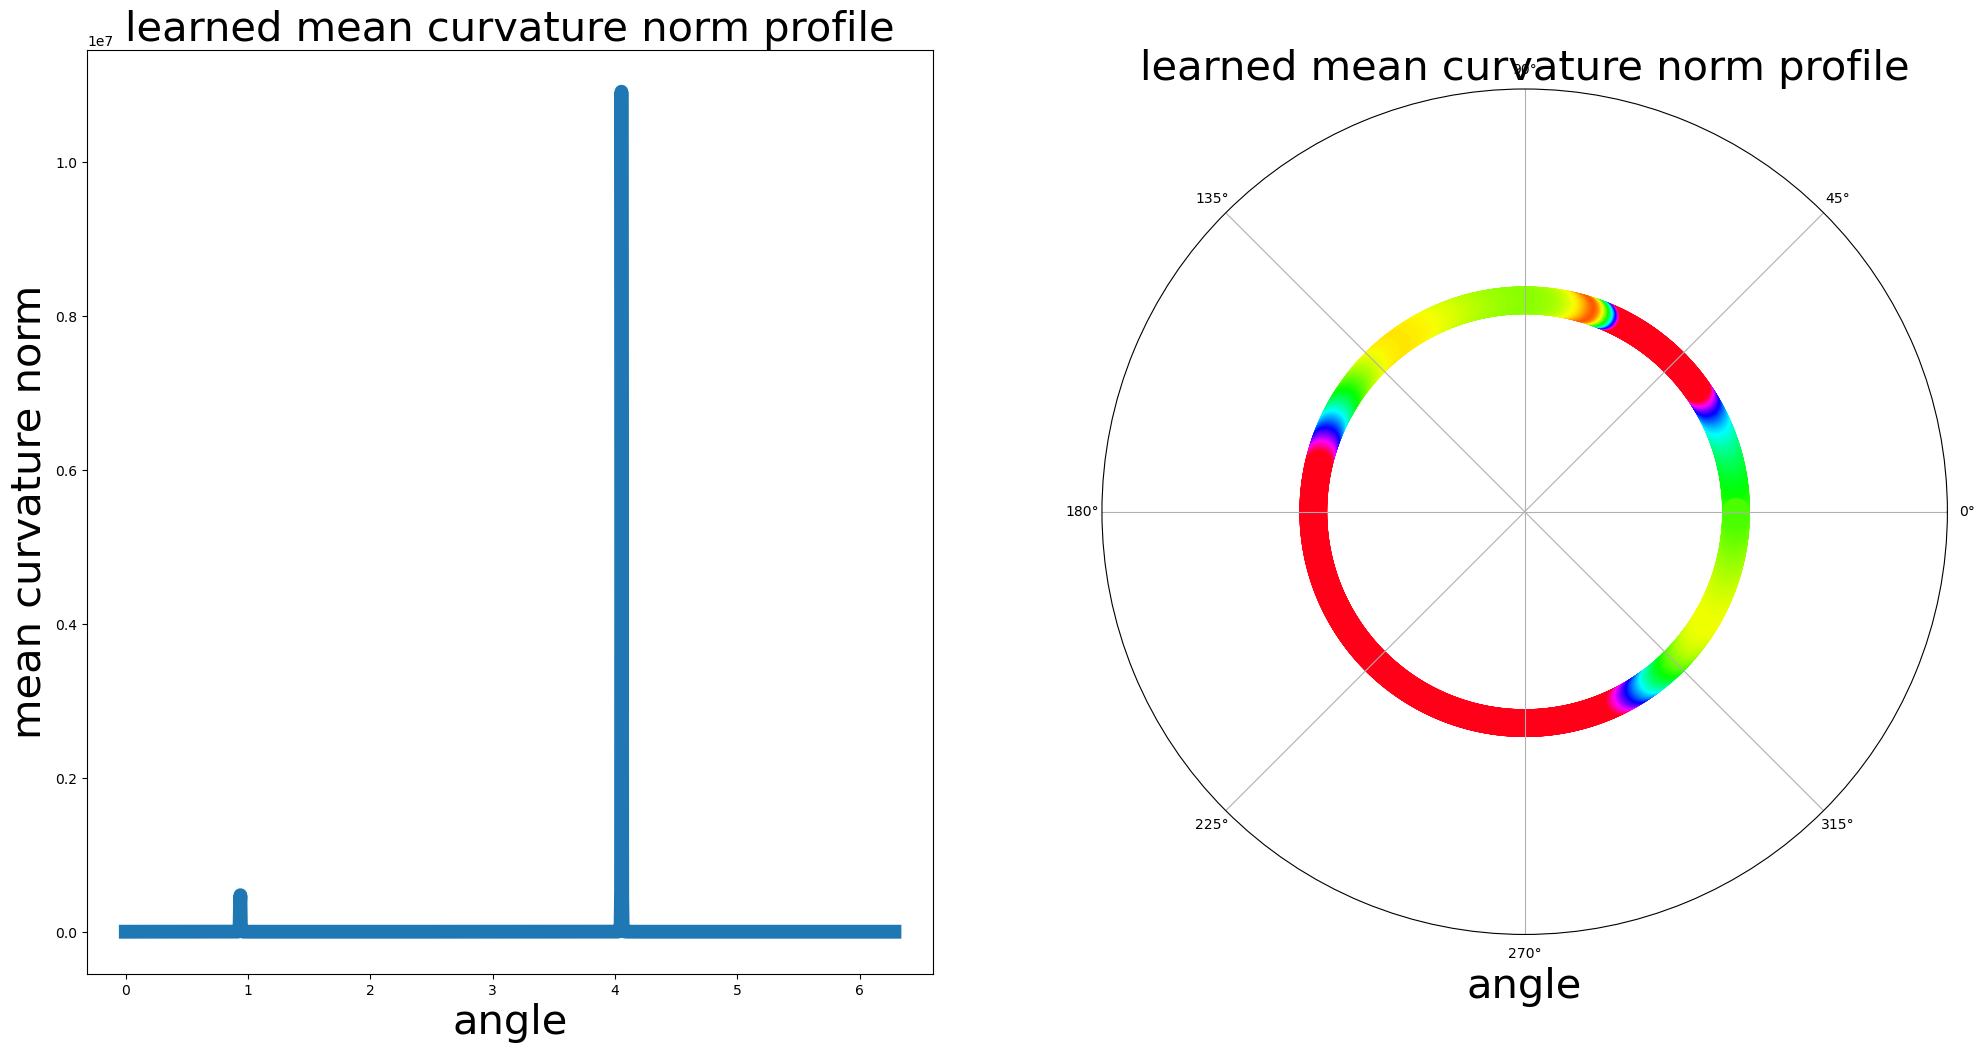

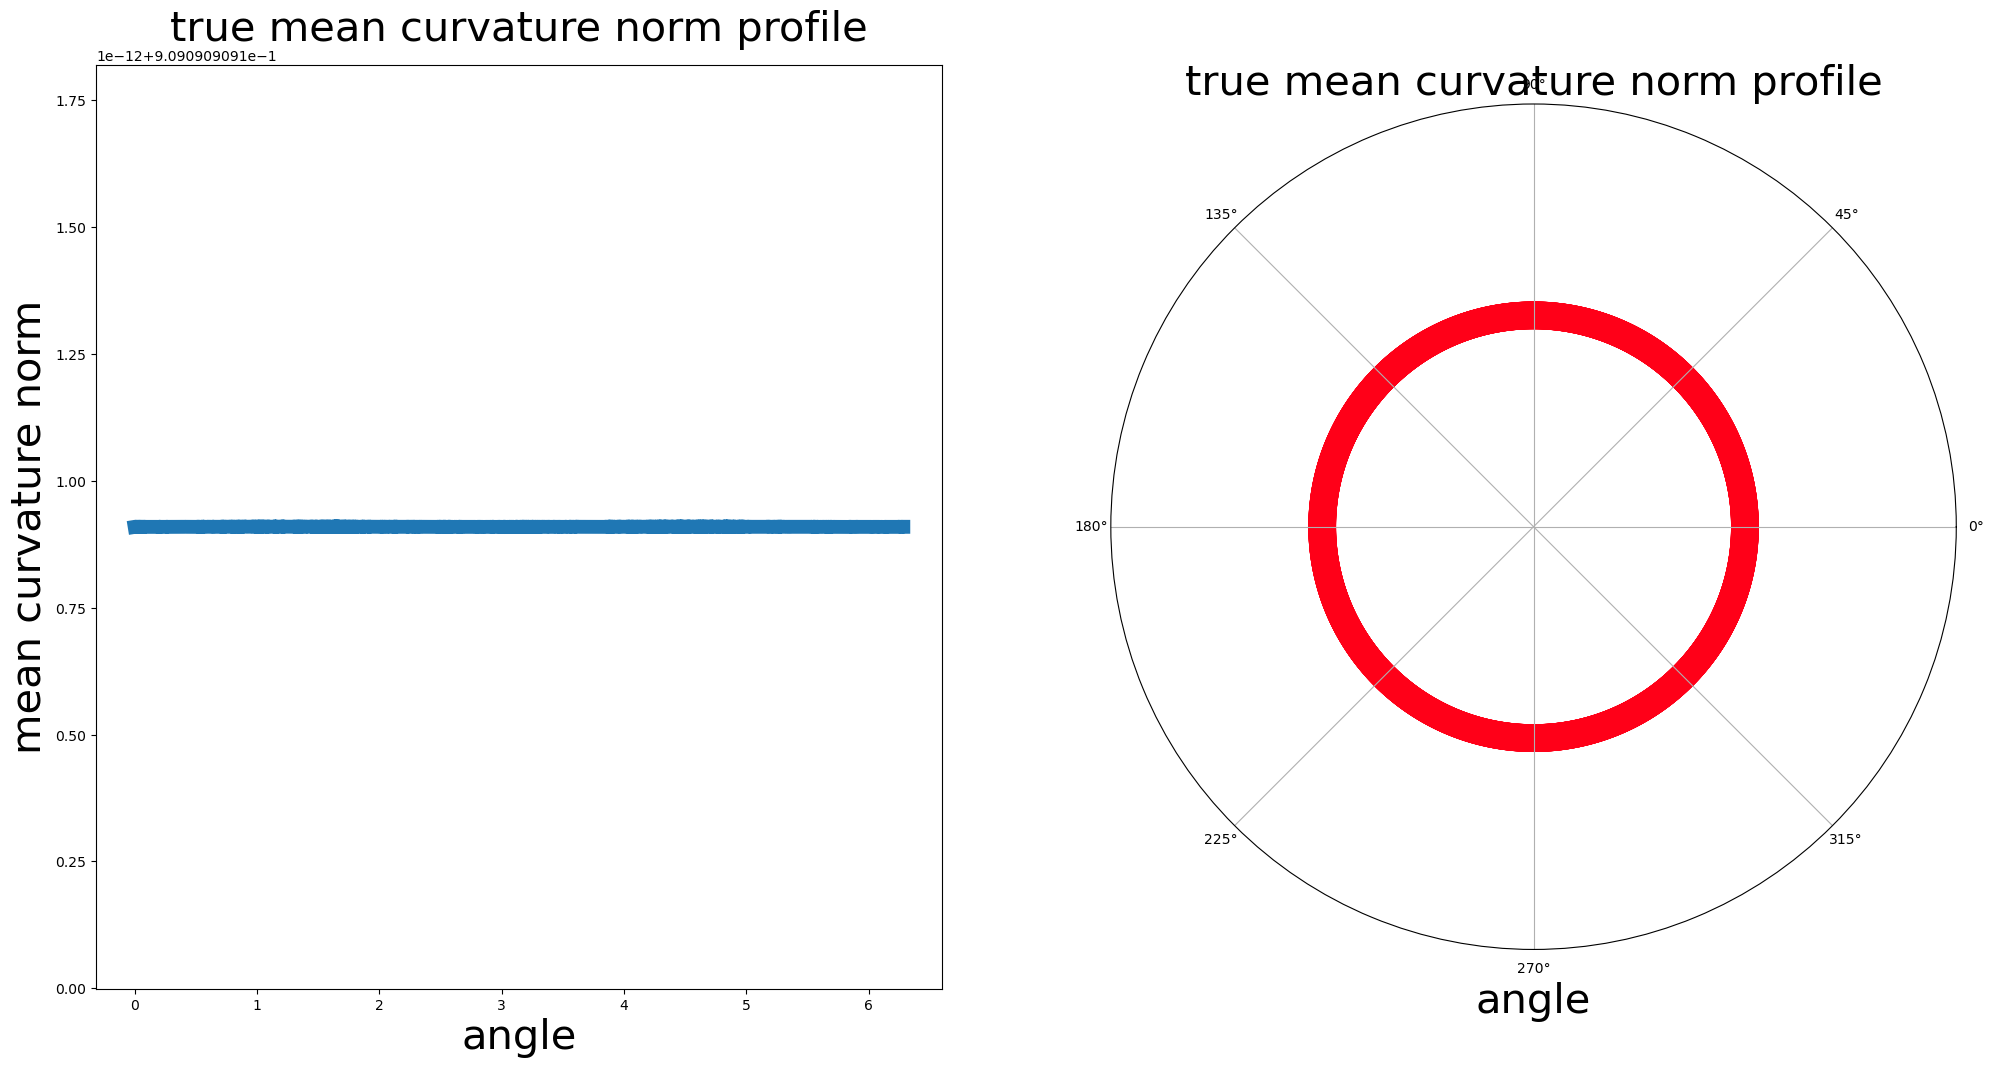

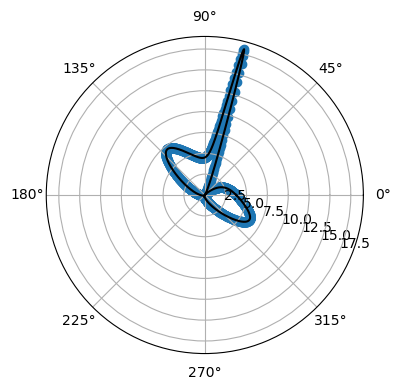

In [92]:
all_data = []
all_labels = []

for data, labels in test_loader:
    all_data.append(data)
    all_labels.append(labels)

all_data = torch.cat(all_data)
all_labels = torch.cat(all_labels)

utils.curvature_compute_plot(config, all_data, all_labels, toroidal_model)

### Save trained models

In [93]:
#modelutils.save_model(toroidal_model, model_config)

### Load pretrained models

In [94]:
#model = modelutils.load_model("gaussian_1740054584")
#model = toroidal_model

### Visualizing the latent space

In [95]:
#utils.plot_test_latents_on_torus(toroidal_model, test_loader, device)

#### Visualize reconstructed mnist images

In [96]:
#utils.show_recon_mnist(toroidal_model, test_loader, device)